In [1]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
X, y = make_circles(n_samples=1000, noise=0.03, factor=0.5,random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
def plot_decision_boundary(model, X, y):
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  grid = np.c_[xx.ravel(), yy.ravel()]
  pred_func = model.predict(grid)
  pred_func = np.round(pred_func).reshape(xx.shape)
  plt.contourf(xx, yy, pred_func, alpha=0.8, cmap='viridis')
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='viridis')
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.show()


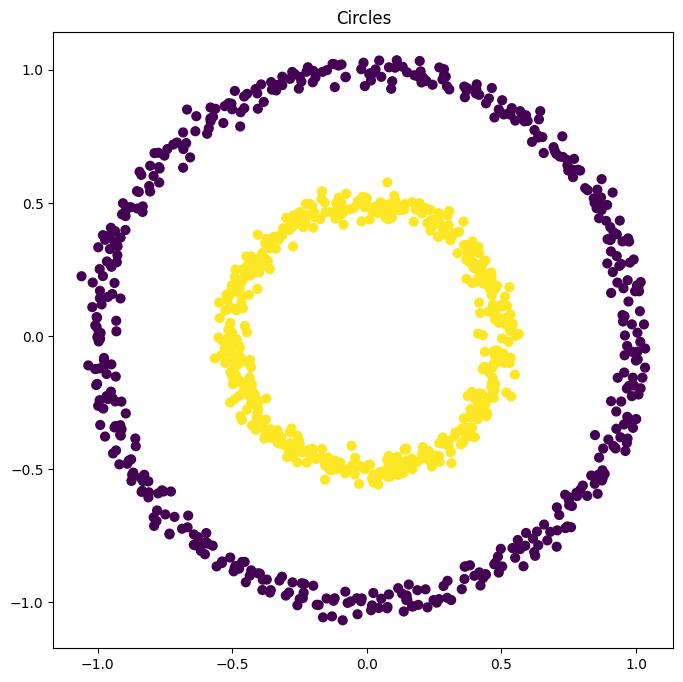

In [5]:
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='viridis')
plt.title("Circles")
plt.show()

In [6]:
X_train.shape

(800, 2)

In [8]:
base_model_circles = tf.keras.Sequential([
  tf.keras.layers.Dense(8, activation='relu', input_shape=(2,)),
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

base_model_circles.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

base_model_circles_loss = base_model_circles.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

loss, accuracy = base_model_circles.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.2f}")

Epoch 1/50
25/25 [==============================] - 1s 10ms/step - loss: 0.6886 - accuracy: 0.5188 - val_loss: 0.6915 - val_accuracy: 0.4600
Epoch 2/50
25/25 [==============================] - 0s 5ms/step - loss: 0.6810 - accuracy: 0.5350 - val_loss: 0.6871 - val_accuracy: 0.4700
Epoch 3/50
25/25 [==============================] - 0s 5ms/step - loss: 0.6751 - accuracy: 0.5300 - val_loss: 0.6834 - val_accuracy: 0.4600
Epoch 4/50
25/25 [==============================] - 0s 5ms/step - loss: 0.6696 - accuracy: 0.5312 - val_loss: 0.6791 - val_accuracy: 0.4750
Epoch 5/50
25/25 [==============================] - 0s 4ms/step - loss: 0.6639 - accuracy: 0.5425 - val_loss: 0.6752 - val_accuracy: 0.4850
Epoch 6/50
25/25 [==============================] - 0s 4ms/step - loss: 0.6586 - accuracy: 0.5475 - val_loss: 0.6713 - val_accuracy: 0.4900
Epoch 7/50
25/25 [==============================] - 0s 4ms/step - loss: 0.6528 - accuracy: 0.5625 - val_loss: 0.6656 - val_accuracy: 0.5050
Epoch 8/50
25/25 [=

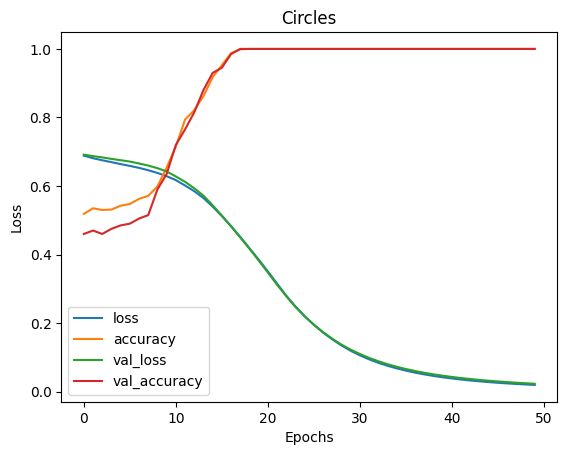

In [9]:
pd.DataFrame(base_model_circles_loss.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Circles")
plt.show()

313/313 [==============================] - 1s 2ms/step


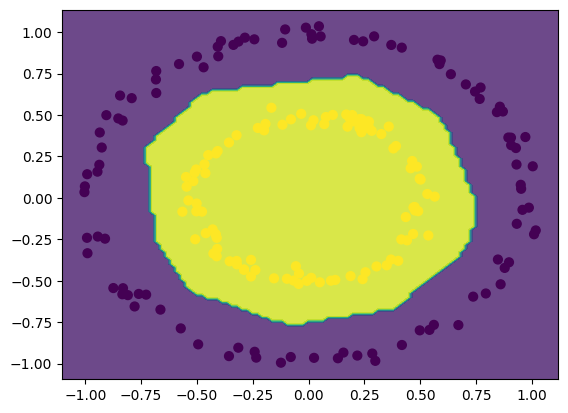

In [12]:
plot_decision_boundary(base_model_circles, X_test, y_test)